In [1]:
#import pandas as pd
#from sklearn.model_selection import train_test_split
#from sklearn.neighbors import KNeighborsClassifier
#from sklearn.preprocessing import StandardScaler
#from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import matplotlib.pyplot as plt
from sklearn import tree
import pandas as pd 
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.DataFrame({
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain',
                'Overcast','Sunny','Sunny','Rain','Sunny',
                'Overcast','Overcast','Rain'],

    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool',
                    'Cool','Mild','Cool','Mild','Mild',
                    'Mild','Hot','Mild'],

    'Humidity': ['High','High','High','High','Normal','Normal',
                 'Normal','High','Normal','Normal','Normal',
                 'High','Normal','High'],

    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong',
             'Strong','Weak','Weak','Weak','Strong',
             'Strong','Weak','Strong'],

    'Play': ['No','No','Yes','Yes','Yes','No',
             'Yes','No','Yes','Yes','Yes',
             'Yes','Yes','No']
})

In [3]:
data.head()

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


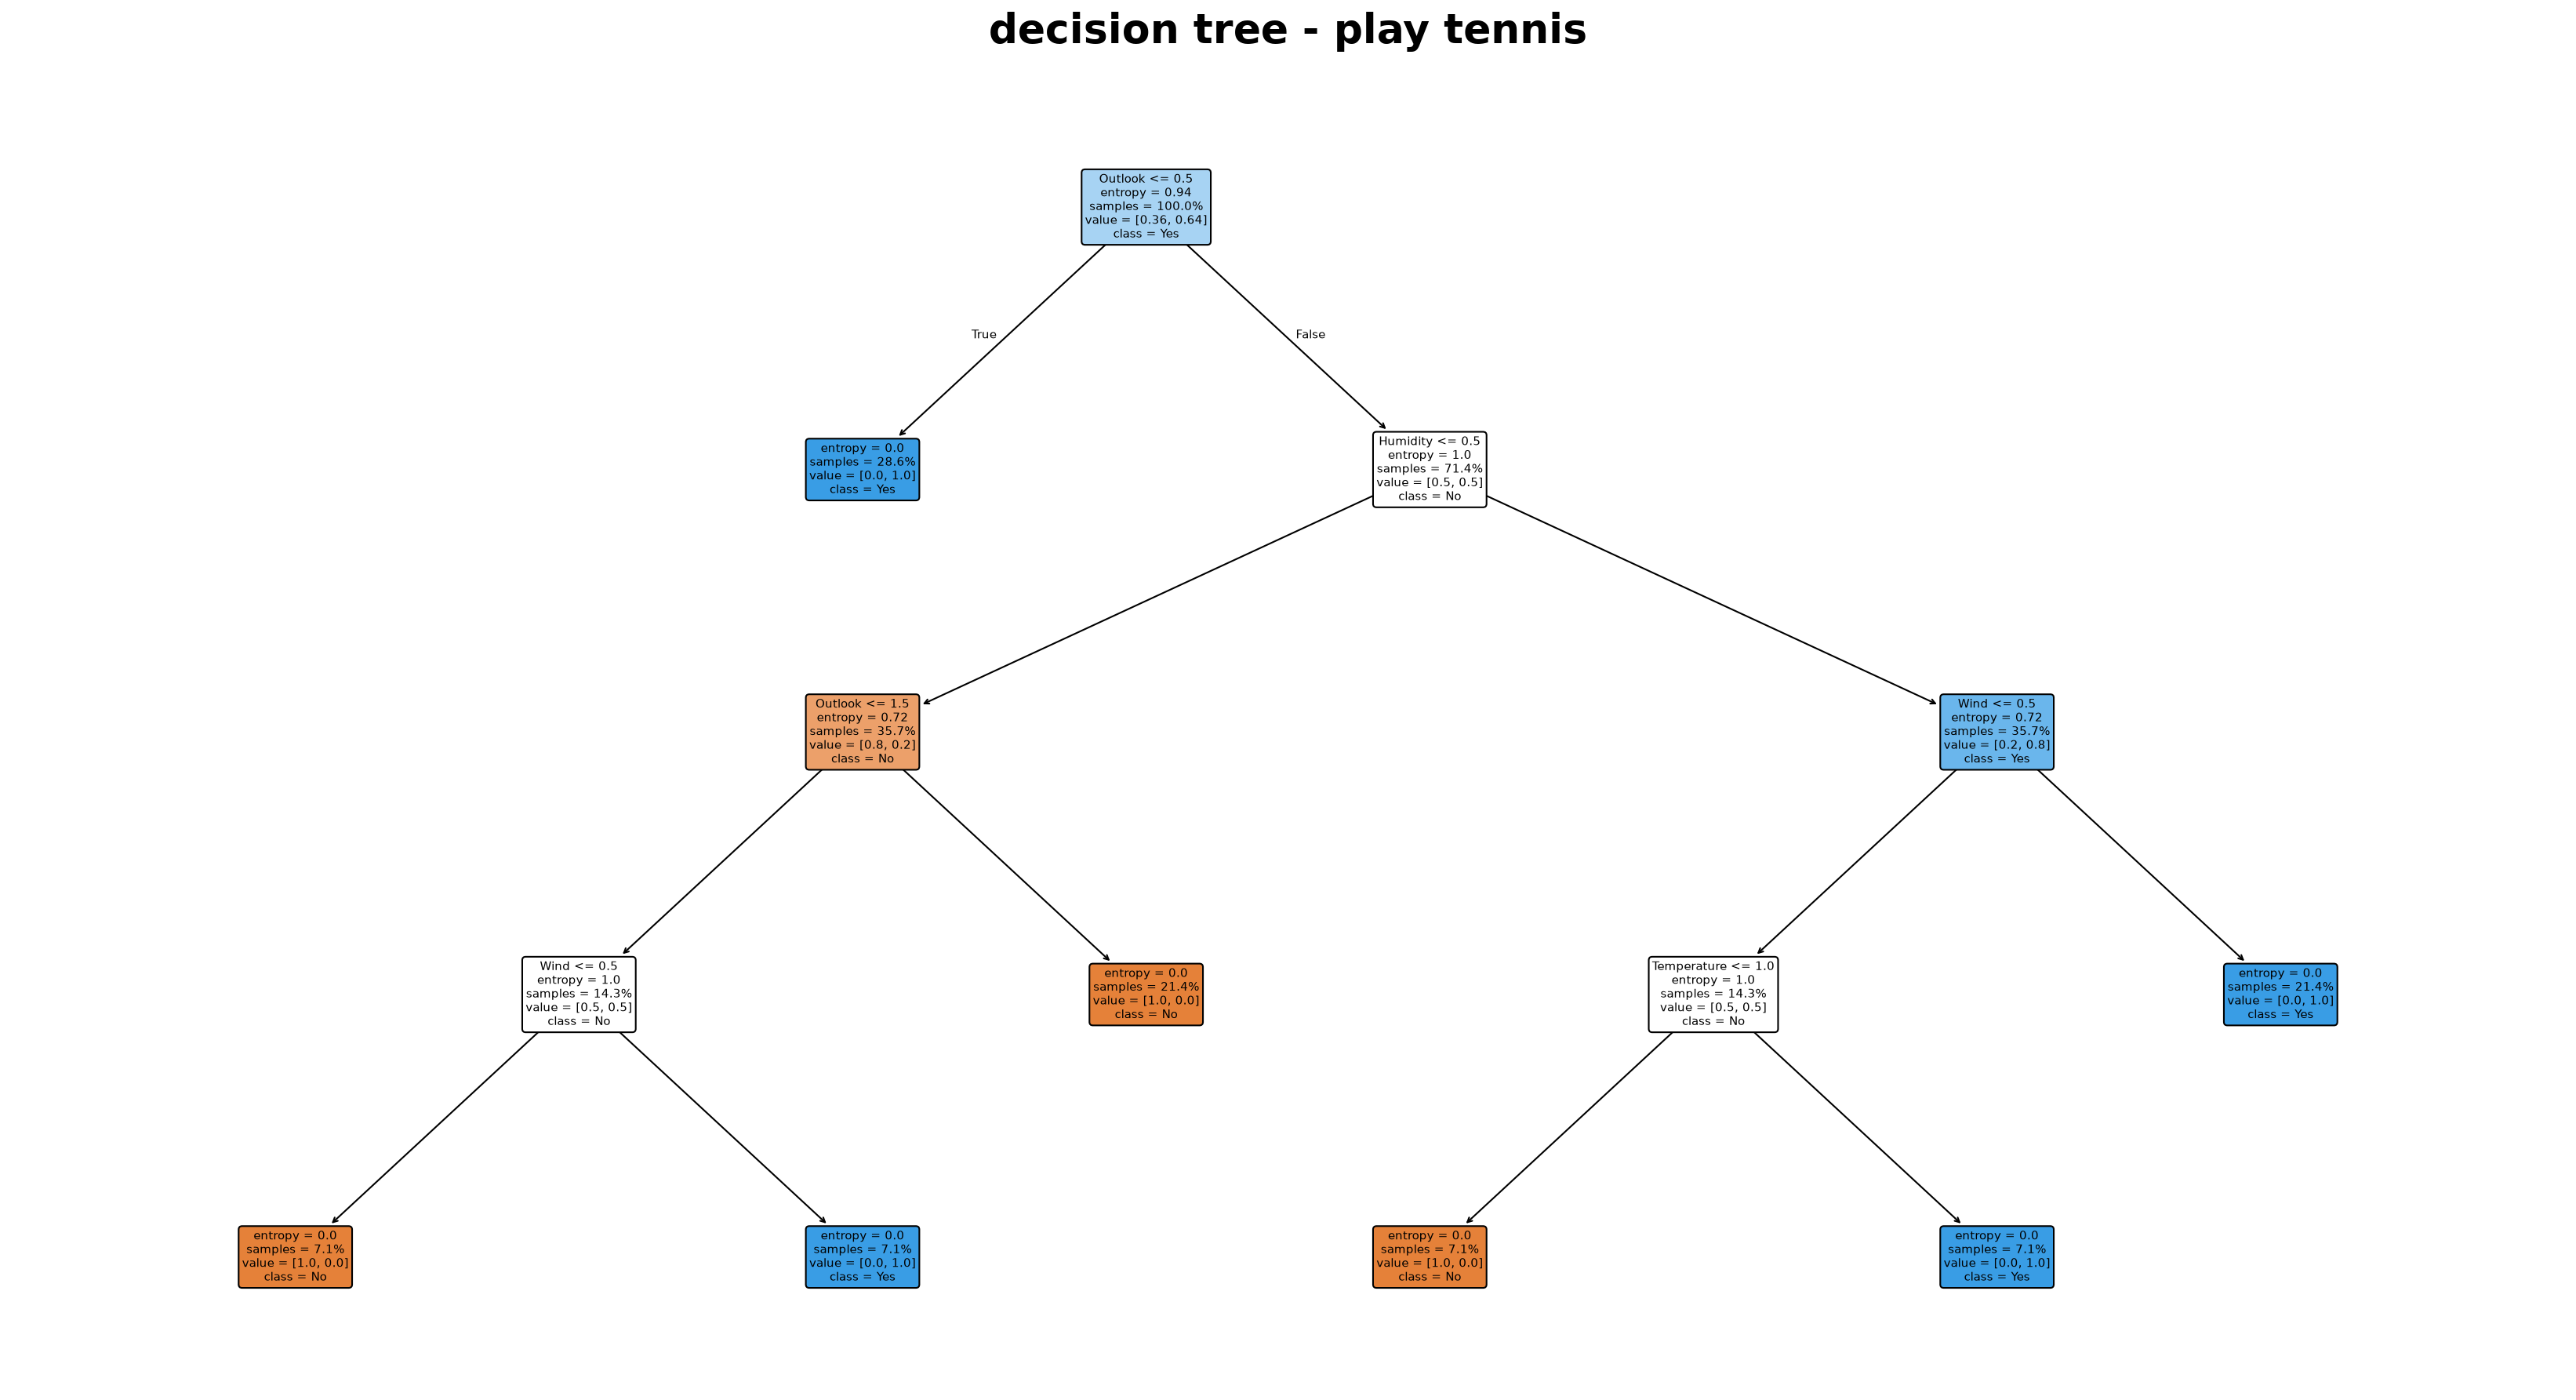

In [4]:
encoder = LabelEncoder()

for col in data.columns:
    data[col] = encoder.fit_transform(data[col])
    
x = data.drop("Play",axis=1)
y = data["Play"]

###train the model

model = tree.DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
model.fit(x,y)

##tree plot
plt.figure(figsize=(22,12),dpi=150)
tree.plot_tree(
    model,
    feature_names=["Outlook","Temperature","Humidity","Wind","Play"],
    class_names=["No","Yes"],
    filled=True,
    rounded=True,
    fontsize=7,
    proportion=True,
    precision=2
)
plt.title("decision tree - play tennis",fontweight="bold",pad=20,fontsize=25)
plt.tight_layout()
plt.show()